In [9]:
import pandas as pd


from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/neo_data.csv")
df.head()

,ID,Neo Reference ID,Name,Limited Name,Designation,NASA JPL URL,Absolute Magnitude (H),Min Diameter (km),Max Diameter (km),Min Diameter (m),...,Close Approach Date (Full),Epoch Date Close Approach,Relative Velocity (km/s),Relative Velocity (km/h),Relative Velocity (miles/h),Miss Distance (astronomical),Miss Distance (lunar),Miss Distance (km),Miss Distance (miles),Orbiting Body
0,2000433,2000433,433 Eros (A898 PA),Eros,433,http://ssd.jpl.nasa.gov/sbdb.cgi?sstr=2000433,10.41,22.006703,49.208483,22006.702711,...,1900-Dec-27 01:30,-2177879400000,5.578619,20083.029075,12478.813260,0.314929,122.507447,4.711273e+07,2.927449e+07,Earth
1,2000433,2000433,433 Eros (A898 PA),Eros,433,http://ssd.jpl.nasa.gov/sbdb.cgi?sstr=2000433,10.41,22.006703,49.208483,22006.702711,...,1907-Nov-05 03:31,-1961526540000,4.394491,15820.167199,9830.036668,0.471486,183.407876,7.053323e+07,4.382732e+07,Earth
2,2000433,2000433,433 Eros (A898 PA),Eros,433,http://ssd.jpl.nasa.gov/sbdb.cgi?sstr=2000433,10.41,22.006703,49.208483,22006.702711,...,1917-Apr-20 21:19,-1663036860000,4.816784,17340.422466,10774.664171,0.499257,194.211053,7.468781e+07,4.640886e+07,Earth
3,2000433,2000433,433 Eros (A898 PA),Eros,433,http://ssd.jpl.nasa.gov/sbdb.cgi?sstr=2000433,10.41,22.006703,49.208483,22006.702711,...,1924-Mar-05 22:13,-1446083220000,4.596055,16545.797588,10280.915173,0.359786,139.956944,5.382329e+07,3.344424e+07,Earth
4,2000433,2000433,433 Eros (A898 PA),Eros,433,http://ssd.jpl.nasa.gov/sbdb.cgi?sstr=2000433,10.41,22.006703,49.208483,22006.702711,...,1931-Jan-30 04:07,-1228247580000,5.920819,21314.946723,13244.278979,0.174073,67.714454,2.604097e+07,1.618111e+07,Earth


In [11]:
from sklearn.model_selection import train_test_split

df_cleaned = df.dropna()

df_X = df_cleaned[["Absolute Magnitude (H)", "Max Diameter (m)", "Relative Velocity (miles/h)", "Miss Distance (miles)"]]

df_X.head()

,Absolute Magnitude (H),Max Diameter (m),Relative Velocity (miles/h),Miss Distance (miles)
0,10.41,49208.483223,12478.813260,2.927449e+07
1,10.41,49208.483223,9830.036668,4.382732e+07
2,10.41,49208.483223,10774.664171,4.640886e+07
3,10.41,49208.483223,10280.915173,3.344424e+07
4,10.41,49208.483223,13244.278979,1.618111e+07


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_X_scaled = scaler.fit_transform(df_X)



In [13]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)

cluster_labels = kmeans.fit_predict(df_X_scaled)

centroids = kmeans.cluster_centers_


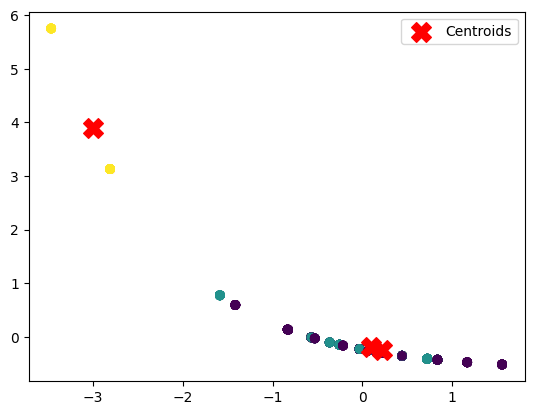

In [14]:
#visualization

import matplotlib.pyplot as plt

plt.scatter(df_X_scaled[:, 0], df_X_scaled[:, 1], c=cluster_labels, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], color='red', marker='X', s=200, label='Centroids')

plt.legend()
plt.show()

In [20]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=3)
cluster_labels = dbscan.fit_predict(df_X_scaled)

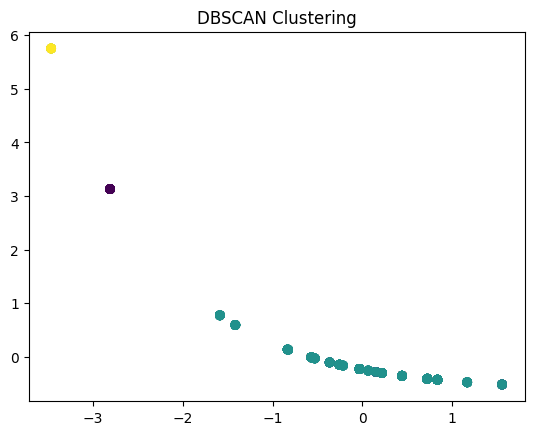

In [22]:
plt.scatter(df_X_scaled[:, 0], df_X_scaled[:, 1], c=cluster_labels, cmap='viridis')
plt.title("DBSCAN Clustering")
plt.show()

In [24]:
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=2, algorithm='auto').fit(df_X_scaled)

distances, indices = nn.kneighbors(df_X_scaled)



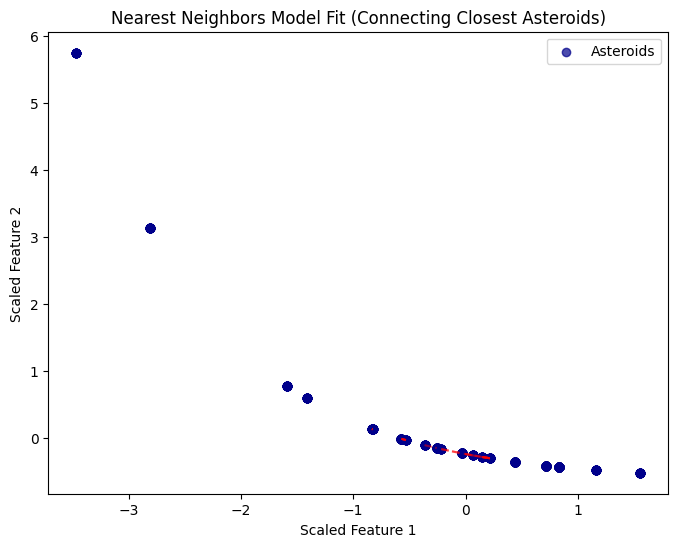

In [25]:
plt.figure(figsize=(8, 6))

plt.scatter(df_X_scaled[:, 0], df_X_scaled[:, 1], color='darkblue', alpha=0.7, label='Asteroids')

for i in range(len(df_X_scaled)):
    neighbor_idx = indices[i, 1] # Index 0 is the point itself, index 1 is its neighbor
    point = df_X_scaled[i]
    neighbor = df_X_scaled[neighbor_idx]
    
    # Plot a line connecting the two points
    plt.plot([point[0], neighbor[0]], [point[1], neighbor[1]], color='red', alpha=0.5, linestyle='--')

plt.title("Nearest Neighbors Model Fit (Connecting Closest Asteroids)")
plt.xlabel("Scaled Feature 1")
plt.ylabel("Scaled Feature 2")
plt.legend()
plt.show()

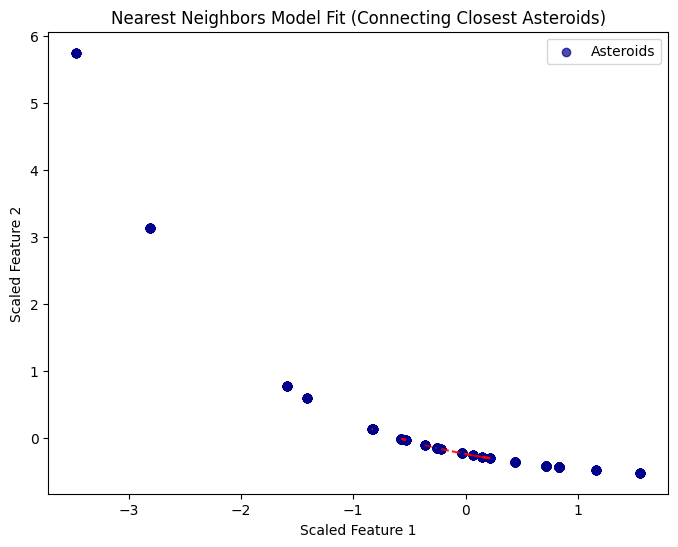

In [ ]:
plt.figure(figsize=(8, 6))

# Plot the actual asteroid data points
plt.scatter(df_X_scaled[:, 0], df_X_scaled[:, 1], color='darkblue', alpha=0.7, label='Asteroids')

# Draw lines between each point and its nearest neighbor explicitly
for i in range(len(df_X_scaled)):
    neighbor_idx = indices[i, 1] 
    point = df_X_scaled[i]
    neighbor = df_X_scaled[neighbor_idx]
    
    x_coords = [point[0], neighbor[0]]
    y_coords = [point[1], neighbor[1]]
    
    # Plot a bold line connecting the two points
    plt.plot(x_coords, y_coords, color='red', alpha=0.6, linestyle='--', linewidth=1.5)

plt.title("Nearest Neighbors Model Fit (Connecting Closest Asteroids)")
plt.xlabel("Scaled Feature 1")
plt.ylabel("Scaled Feature 2")
plt.legend()
plt.show()